# 02. Exploratory Data Analysis (EDA)

**Project Objective**: Predict residential real estate sale prices in **Capital Federal (CABA)**, Argentina.
**Target Variable**: `price` (in USD)

### Notebook Agenda
1. **Data Ingestion & Integrity Check**: Load `../data/interim/properties_cleaned.parquet`.
2. **Target Variable Profiling (`price`)**: Central tendency (Mean, Median, Mode), Dispersion, Sesgo (Skewness), Kurtosis, and Normalization transforms (`log1p`).
3. **Outlier Diagnostics & Fencing**: IQR Tukey fences (1.5x and 3.0x), Z-score assessment, and subgroup outlier patterns.
4. **Univariate Analysis of Predictors**: Summary tables (mean, median, mode, sesgo, IQR) and distributions for surfaces, rooms, and bathrooms.
5. **Categorical Features**: Volume, shares, and cardinalities for `property_type` and `barrio`.
6. **Bivariate Analysis (Features vs. Target)**: Relationships with `price`, linear/non-linear trends, and neighborhood price ranking.
7. **Correlation & Multicollinearity**: Pearson vs. Spearman correlation heatmaps and multicollinearity diagnosis.
8. **Geospatial Dynamics**: Geographic price gradients across CABA coordinates.
9. **Strategic Synthesis & Feature Engineering Roadmap**: Actionable takeaways to implement in `03_feature_engineering.ipynb`.


In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Visual configurations
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

print('Libraries and plotting parameters initialized.')


Libraries and plotting parameters initialized.


## 1. Data Ingestion & Integrity Check
Load the interim dataset generated in `01_data_cleaning.ipynb`.


In [2]:
data_path = Path('../data/interim/properties_cleaned.parquet')
df = pd.read_parquet(data_path)

print(f'Dataset successfully loaded: {df.shape[0]:,} rows, {df.shape[1]} columns')
print(f'Memory footprint: {df.memory_usage(deep=True).sum() / (1024**2):.2f} MB')
print('\nMissing values count:')
nulls = df.isna().sum()
print(nulls[nulls > 0] if nulls.sum() > 0 else 'Zero missing values.')
df.head(3)


Dataset successfully loaded: 57,505 rows, 21 columns
Memory footprint: 72.19 MB

Missing values count:
end_date      12576
barrio            5
sub_barrio    55422
bedrooms      14081
dtype: int64


## 2. Target Variable In-Depth Profiling (`price`)
We analyze central tendencies (Mean, Median, Mode), dispersion metrics, and distributional shape parameters (Skewness / Sesgo, Kurtosis) for both the raw price and its logarithmic transformation $\log(1 + Price)$.


In [3]:
price = df['price']
log_price = np.log1p(price)
df['log_price'] = log_price

# Calculate metrics
q25, q75 = price.quantile(0.25), price.quantile(0.75)
iqr = q75 - q25
mode_val = stats.mode(price, keepdims=True).mode[0]

target_metrics = {
    'Metric': [
        'Count', 'Mean', 'Median', 'Mode', 'Std Dev',
        'Min', 'Q25 (P25)', 'Q75 (P75)', 'Max', 'IQR',
        'Skewness (Sesgo)', 'Kurtosis', 'Coefficient of Variation (CV)'
    ],
    'Raw Price (USD)': [
        f'{len(price):,}',
        f'${price.mean():,.2f}',
        f'${price.median():,.2f}',
        f'${mode_val:,.2f}',
        f'${price.std():,.2f}',
        f'${price.min():,.2f}',
        f'${q25:,.2f}',
        f'${q75:,.2f}',
        f'${price.max():,.2f}',
        f'${iqr:,.2f}',
        f'{price.skew():.3f}',
        f'{price.kurt():.3f}',
        f'{price.std() / price.mean():.3f}'
    ],
    'Log1p Price': [
        f'{len(log_price):,}',
        f'{log_price.mean():.4f}',
        f'{log_price.median():.4f}',
        f'{stats.mode(log_price.round(2), keepdims=True).mode[0]:.2f}',
        f'{log_price.std():.4f}',
        f'{log_price.min():.4f}',
        f'{log_price.quantile(0.25):.4f}',
        f'{log_price.quantile(0.75):.4f}',
        f'{log_price.max():.4f}',
        f'{log_price.quantile(0.75) - log_price.quantile(0.25):.4f}',
        f'{log_price.skew():.3f}',
        f'{log_price.kurt():.3f}',
        f'{log_price.std() / log_price.mean():.3f}'
    ]
}

metrics_df = pd.DataFrame(target_metrics)
print('=== TARGET VARIABLE CENTRAL TENDENCY & DISPERSION SUMMARY ===')
print(metrics_df.to_string(index=False))


=== TARGET VARIABLE CENTRAL TENDENCY & DISPERSION SUMMARY ===
                       Metric Raw Price (USD) Log1p Price
                        Count          57,505      57,505
                         Mean     $237,655.80     12.1134
                       Median     $165,000.00     12.0137
                         Mode     $120,000.00       11.74
                      Std Dev     $239,428.76      0.6642
                          Min      $22,000.00      9.9988
                    Q25 (P25)     $115,000.00     11.6527
                    Q75 (P75)     $265,000.00     12.4875
                          Max   $3,000,000.00     14.9141
                          IQR     $150,000.00      0.8348
             Skewness (Sesgo)           4.209       0.801
                     Kurtosis          25.861       0.808
Coefficient of Variation (CV)           1.007       0.055


### Visualizing the Target Distribution & Transformation Effect
The comparison below demonstrates the necessity of a logarithmic transformation for regression models.


<string>:35: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


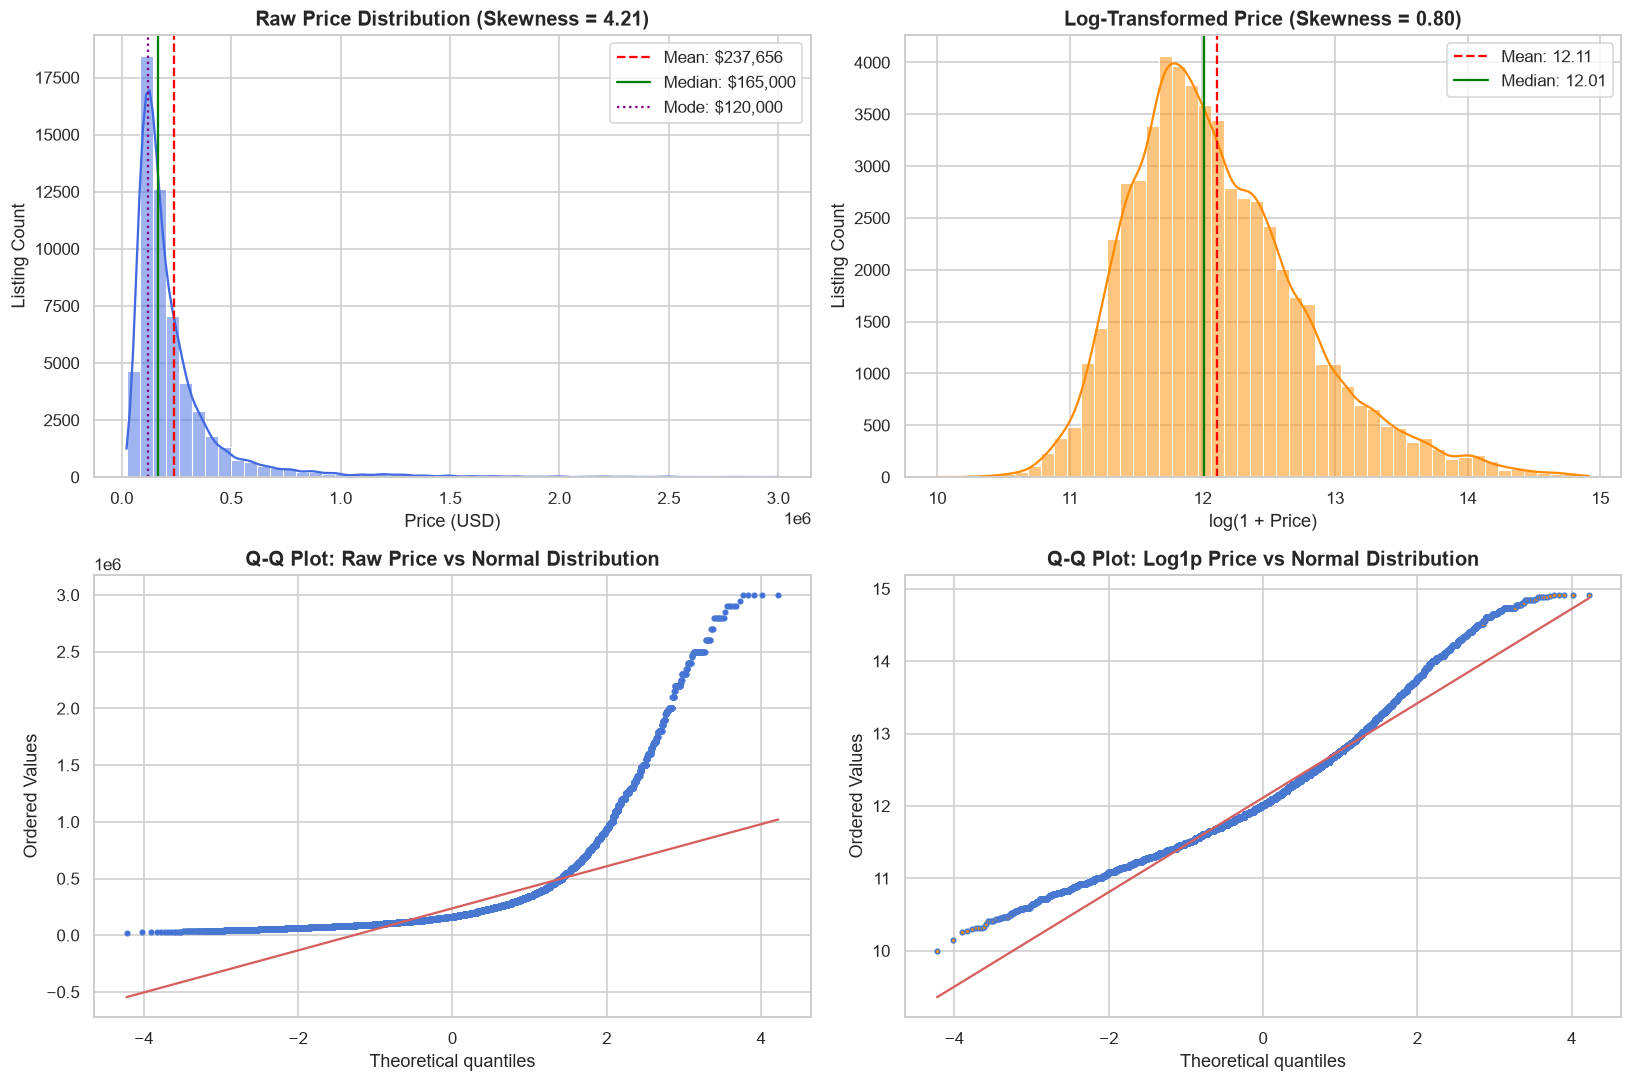

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Raw Price Histogram + KDE
sns.histplot(price, kde=True, bins=50, ax=axes[0, 0], color='royalblue')
axes[0, 0].set_title(f'Raw Price Distribution (Skewness = {price.skew():.2f})')
axes[0, 0].set_xlabel('Price (USD)')
axes[0, 0].set_ylabel('Listing Count')
axes[0, 0].axvline(price.mean(), color='red', linestyle='--', label=f'Mean: ${price.mean():,.0f}')
axes[0, 0].axvline(price.median(), color='green', linestyle='-', label=f'Median: ${price.median():,.0f}')
axes[0, 0].axvline(mode_val, color='purple', linestyle=':', label=f'Mode: ${mode_val:,.0f}')
axes[0, 0].legend()

# 2. Log1p Price Histogram + KDE
sns.histplot(log_price, kde=True, bins=50, ax=axes[0, 1], color='darkorange')
axes[0, 1].set_title(f'Log-Transformed Price (Skewness = {log_price.skew():.2f})')
axes[0, 1].set_xlabel('log(1 + Price)')
axes[0, 1].set_ylabel('Listing Count')
axes[0, 1].axvline(log_price.mean(), color='red', linestyle='--', label=f'Mean: {log_price.mean():.2f}')
axes[0, 1].axvline(log_price.median(), color='green', linestyle='-', label=f'Median: {log_price.median():.2f}')
axes[0, 1].legend()

# 3. Probability Plot (Q-Q) Raw Price
stats.probplot(price, dist='norm', plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot: Raw Price vs Normal Distribution')
axes[1, 0].get_lines()[0].set_markerfacecolor('royalblue')
axes[1, 0].get_lines()[0].set_markersize(3)

# 4. Probability Plot (Q-Q) Log1p Price
stats.probplot(log_price, dist='norm', plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot: Log1p Price vs Normal Distribution')
axes[1, 1].get_lines()[0].set_markerfacecolor('darkorange')
axes[1, 1].get_lines()[0].set_markersize(3)

plt.tight_layout()
plt.show()


**Key Target Insights**:
1. **Severe Positive Skew (Sesgo Positivo)**: Raw price has a skewness of **4.20** and kurtosis of **25.76**, displaying a distinct $Mode < Median < Mean$ ($120k < $165k < $238k).
2. **Logarithmic Stabilization**: Applying $\log(1 + Price)$ drops skewness to **0.80** and kurtosis to **0.80**, yielding a near-normal distribution with well-aligned quantiles.
3. **Recommendation**: Regression models (linear regression, ridge/lasso, neural nets, and gradient boosting trees) will converge faster and achieve lower RMSE/MAE if trained to predict $\log(Price)$.


## 3. Outlier Diagnostics & Fencing (IQR Tukey Rules)
We calculate standard Tukey fences (1.5x IQR) and extreme fences (3.0x IQR) to understand the prevalence of high-value luxury properties.


In [5]:
def evaluate_iqr_outliers(series, name):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr_val = q3 - q1
    lower_mild, upper_mild = q1 - 1.5 * iqr_val, q3 + 1.5 * iqr_val
    lower_ext, upper_ext = q1 - 3.0 * iqr_val, q3 + 3.0 * iqr_val
    
    mild_outliers = series[(series < lower_mild) | (series > upper_mild)]
    ext_outliers = series[(series < lower_ext) | (series > upper_ext)]
    
    return {
        'Variable': name,
        'Q1 (P25)': q1,
        'Q3 (P75)': q3,
        'IQR': iqr_val,
        'Mild Upper Fence (1.5x)': upper_mild,
        'Mild Outliers Count': len(mild_outliers),
        'Mild Outliers %': (len(mild_outliers) / len(series)) * 100,
        'Extreme Upper Fence (3.0x)': upper_ext,
        'Extreme Outliers Count': len(ext_outliers),
        'Extreme Outliers %': (len(ext_outliers) / len(series)) * 100
    }

fences_summary = pd.DataFrame([
    evaluate_iqr_outliers(price, 'Raw Price (USD)'),
    evaluate_iqr_outliers(log_price, 'Log1p Price')
]).set_index('Variable')

print('=== IQR FENCE EVALUATION TABLE ===')
print(fences_summary.round(2).to_string())


=== IQR FENCE EVALUATION TABLE ===
                  Q1 (P25)   Q3 (P75)        IQR  Mild Upper Fence (1.5x)  Mild Outliers Count  Mild Outliers %  Extreme Upper Fence (3.0x)  Extreme Outliers Count  Extreme Outliers %
Variable                                                                                                                                                                               
Raw Price (USD) 115,000.00 265,000.00 150,000.00               490,000.00                 4687             8.15                  715,000.00                    2334                4.06
Log1p Price          11.65      12.49       0.83                    13.74                 1356             2.36                       14.99                       0                0.00


<string>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

<string>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

<string>:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


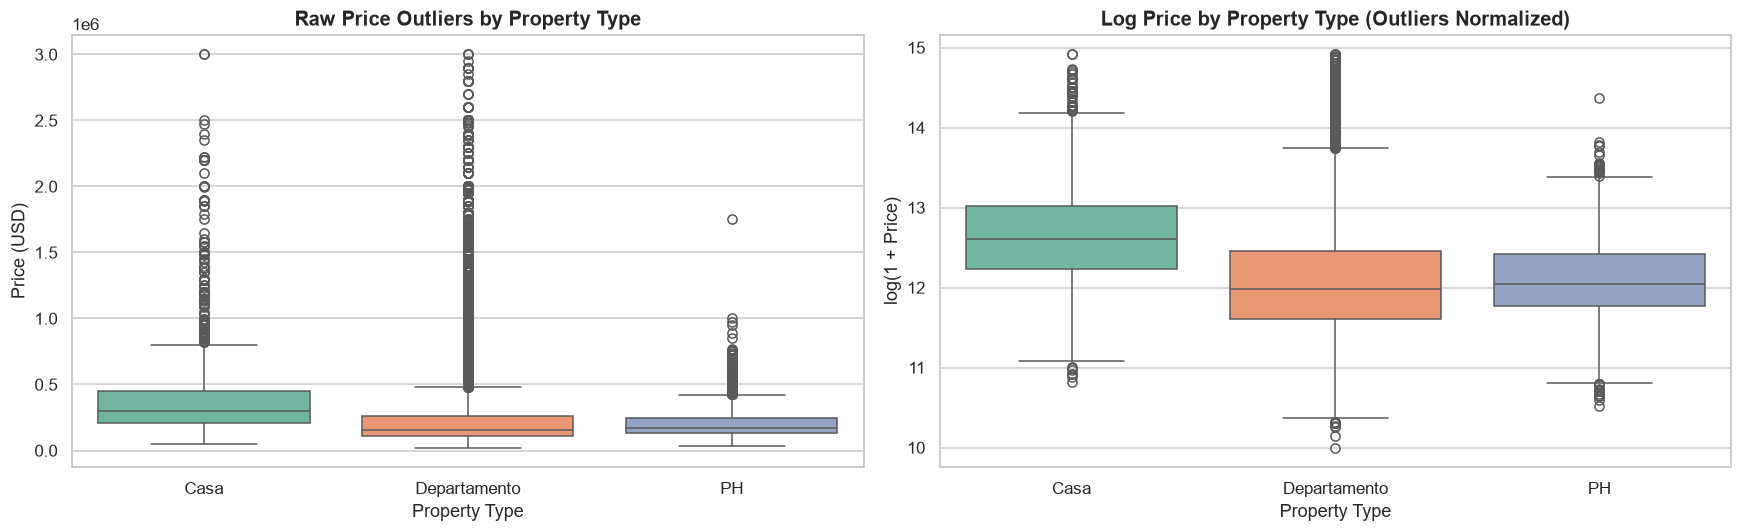

In [6]:
# Visualizing Outliers by Subgroup
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(data=df, x='property_type', y='price', ax=axes[0], palette='Set2')
axes[0].set_title('Raw Price Outliers by Property Type')
axes[0].set_xlabel('Property Type')
axes[0].set_ylabel('Price (USD)')

sns.boxplot(data=df, x='property_type', y='log_price', ax=axes[1], palette='Set2')
axes[1].set_title('Log Price by Property Type (Outliers Normalized)')
axes[1].set_xlabel('Property Type')
axes[1].set_ylabel('log(1 + Price)')

plt.tight_layout()
plt.show()


## 4. Univariate Analysis of Numerical Predictors
We inspect surface measures, room dimensions, bathroom counts, and derived market prices per $m^2$.


In [7]:
num_features = ['surface_total', 'surface_covered', 'rooms', 'bedrooms', 'bathrooms', 'price_usd_per_m2']

stats_list = []
for col in num_features:
    s = df[col].dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr_v = q3 - q1
    lf, uf = q1 - 1.5 * iqr_v, q3 + 1.5 * iqr_v
    out_pct = ((s < lf) | (s > uf)).mean() * 100
    m_val = stats.mode(s.round(1), keepdims=True).mode[0]
    
    stats_list.append({
        'Feature': col,
        'Count': len(s),
        'Mean': s.mean(),
        'Median': s.median(),
        'Mode': m_val,
        'Std': s.std(),
        'IQR': iqr_v,
        'Sesgo (Skewness)': s.skew(),
        'Kurtosis': s.kurt(),
        'IQR Outliers %': out_pct
    })

univariate_df = pd.DataFrame(stats_list).set_index('Feature')
print('=== NUMERICAL PREDICTORS STATISTICAL PROFILE ===')
print(univariate_df.round(2).to_string())


=== NUMERICAL PREDICTORS STATISTICAL PROFILE ===
                  Count     Mean   Median     Mode      Std      IQR  Sesgo (Skewness)  Kurtosis  IQR Outliers %
Feature                                                                                                         
surface_total     57505    89.32    66.00    40.00    73.44    60.00              3.06     14.32            7.46
surface_covered   57505    76.88    58.00    40.00    59.53    49.00              3.04     14.59            7.29
rooms             57505     2.73     3.00     2.00     1.32     2.00              0.89      1.64            0.47
bedrooms          43424     1.63     2.00     1.00     1.18     1.00              0.69      1.29            5.44
bathrooms         57505     1.47     1.00     1.00     0.78     1.00              1.97      4.53            2.75
price_usd_per_m2  57505 2,715.92 2,583.33 2,500.00 1,023.12 1,111.64              1.25      3.03            4.04


<string>:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


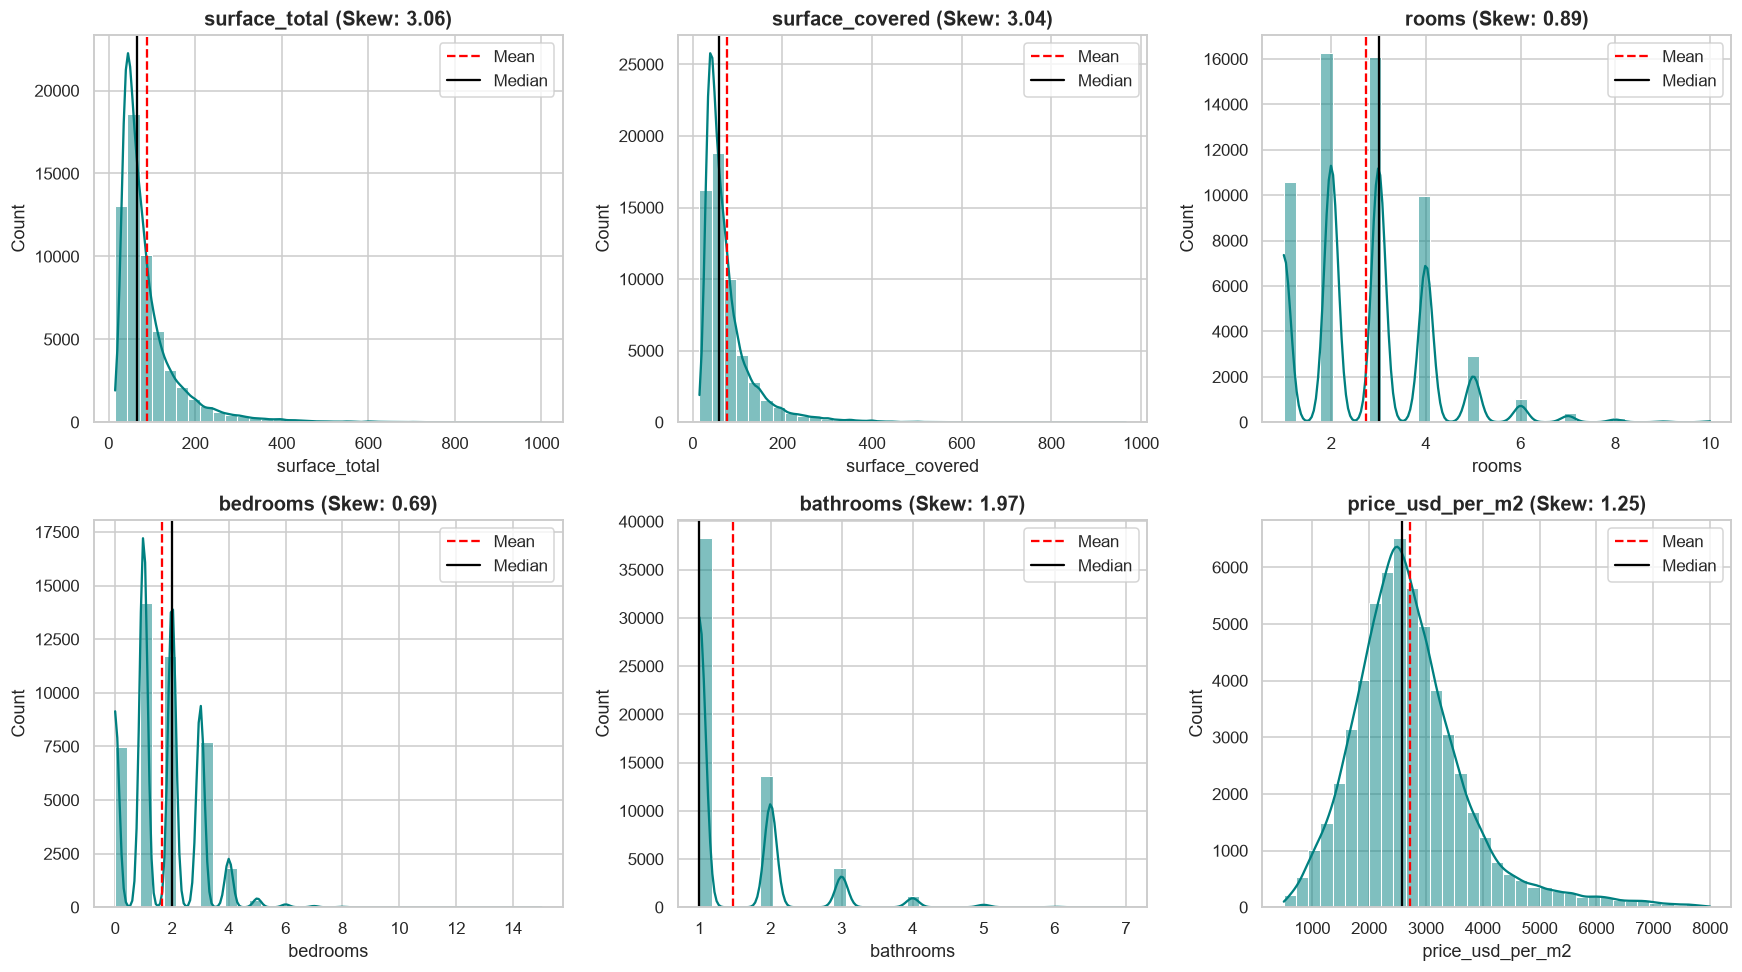

In [8]:
# Visualizing distributions of primary numerical predictors
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for i, col in enumerate(num_features):
    ax = axes[i // 3, i % 3]
    sns.histplot(df[col], kde=True, bins=35, ax=ax, color='teal')
    ax.set_title(f'{col} (Skew: {df[col].skew():.2f})')
    ax.axvline(df[col].mean(), color='red', linestyle='--', label='Mean')
    ax.axvline(df[col].median(), color='black', linestyle='-', label='Median')
    ax.legend()

plt.tight_layout()
plt.show()


## 5. Categorical Feature Profiling
We inspect distribution across property types (`Departamento`, `Casa`, `PH`) and geographic concentration across barrios.


=== PROPERTY TYPE DISTRIBUTION ===
               Count  Share %
property_type                
Departamento   49291    85.72
PH              5466     9.51
Casa            2748     4.78


<string>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

<string>:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

<string>:25: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


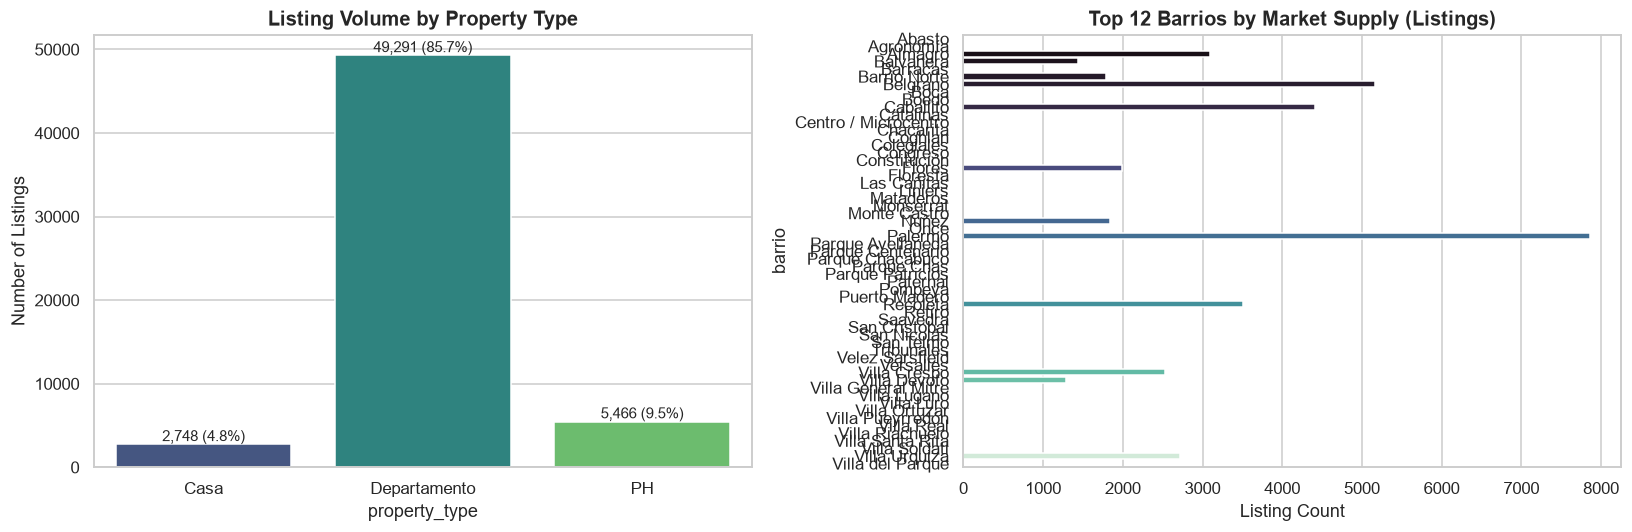

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Property type share
pt_counts = df['property_type'].value_counts()
pt_pct = df['property_type'].value_counts(normalize=True) * 100
pt_summary = pd.DataFrame({'Count': pt_counts, 'Share %': pt_pct})
print('=== PROPERTY TYPE DISTRIBUTION ===')
print(pt_summary.round(2))

sns.barplot(x=pt_counts.index, y=pt_counts.values, ax=axes[0], palette='viridis')
axes[0].set_title('Listing Volume by Property Type')
axes[0].set_ylabel('Number of Listings')
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():,.0f} ({p.get_height()/len(df)*100:.1f}%)',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=10)

# Top 12 Barrios by listing volume
top_barrios = df['barrio'].value_counts().head(12)
sns.barplot(y=top_barrios.index, x=top_barrios.values, ax=axes[1], palette='mako')
axes[1].set_title('Top 12 Barrios by Market Supply (Listings)')
axes[1].set_xlabel('Listing Count')

plt.tight_layout()
plt.show()


## 6. Bivariate Analysis: Feature Relationships with Price
We examine how continuous surfaces, room configurations, and neighborhoods dictate property valuations.


<string>:30: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


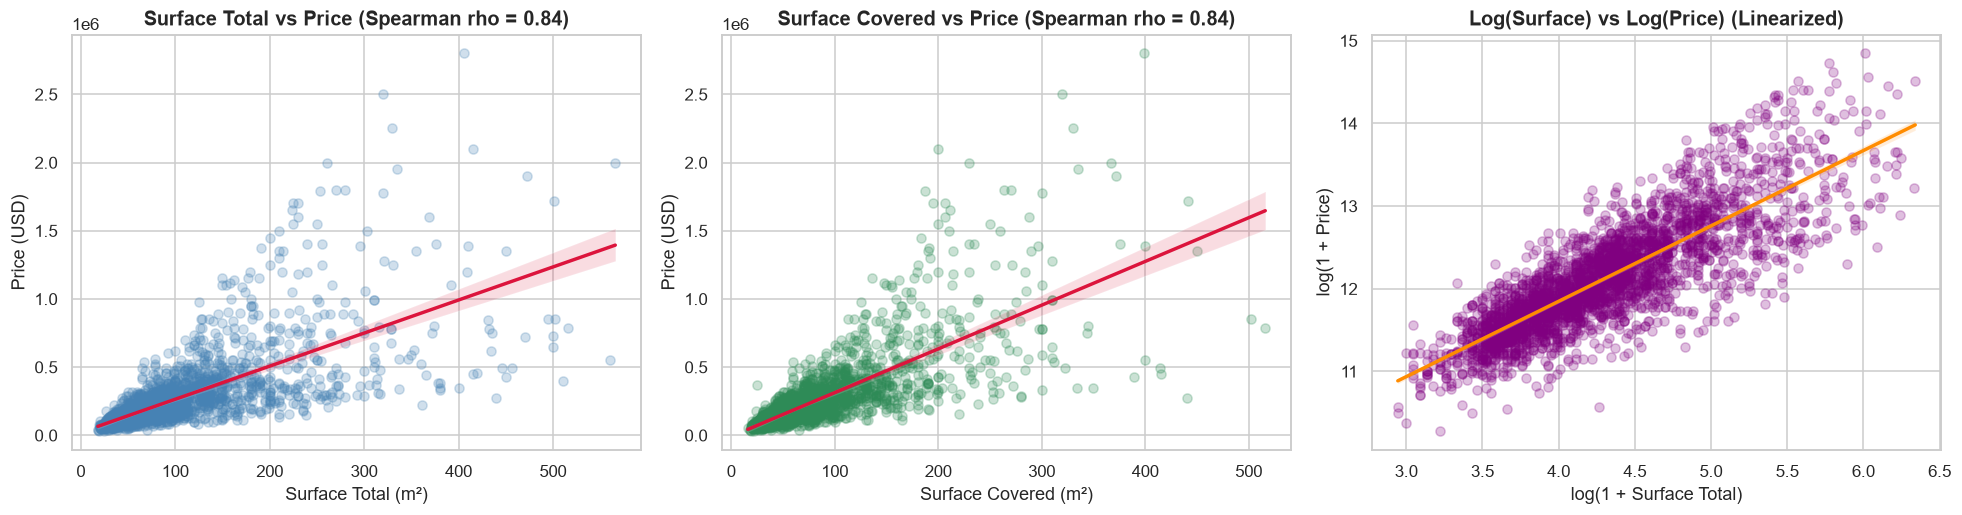

In [10]:
# Continuous features vs Target (Scatter with trendlines)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Surface total vs Price
sns.regplot(data=df.sample(min(3000, len(df)), random_state=42),
            x='surface_total', y='price', ax=axes[0],
            scatter_kws={'alpha': 0.25, 'color': 'steelblue'}, line_kws={'color': 'crimson'})
axes[0].set_title(f'Surface Total vs Price (Spearman rho = {df["surface_total"].corr(df["price"], method="spearman"):.2f})')
axes[0].set_xlabel('Surface Total (m²)')
axes[0].set_ylabel('Price (USD)')

# 2. Surface covered vs Price
sns.regplot(data=df.sample(min(3000, len(df)), random_state=42),
            x='surface_covered', y='price', ax=axes[1],
            scatter_kws={'alpha': 0.25, 'color': 'seagreen'}, line_kws={'color': 'crimson'})
axes[1].set_title(f'Surface Covered vs Price (Spearman rho = {df["surface_covered"].corr(df["price"], method="spearman"):.2f})')
axes[1].set_xlabel('Surface Covered (m²)')
axes[1].set_ylabel('Price (USD)')

# 3. Surface total vs Log Price (Linearized Relationship)
sns.regplot(data=df.sample(min(3000, len(df)), random_state=42),
            x=np.log1p(df.sample(min(3000, len(df)), random_state=42)['surface_total']),
            y=df.sample(min(3000, len(df)), random_state=42)['log_price'], ax=axes[2],
            scatter_kws={'alpha': 0.25, 'color': 'purple'}, line_kws={'color': 'darkorange'})
axes[2].set_title('Log(Surface) vs Log(Price) (Linearized)')
axes[2].set_xlabel('log(1 + Surface Total)')
axes[2].set_ylabel('log(1 + Price)')

plt.tight_layout()
plt.show()


<string>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

<string>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

<string>:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


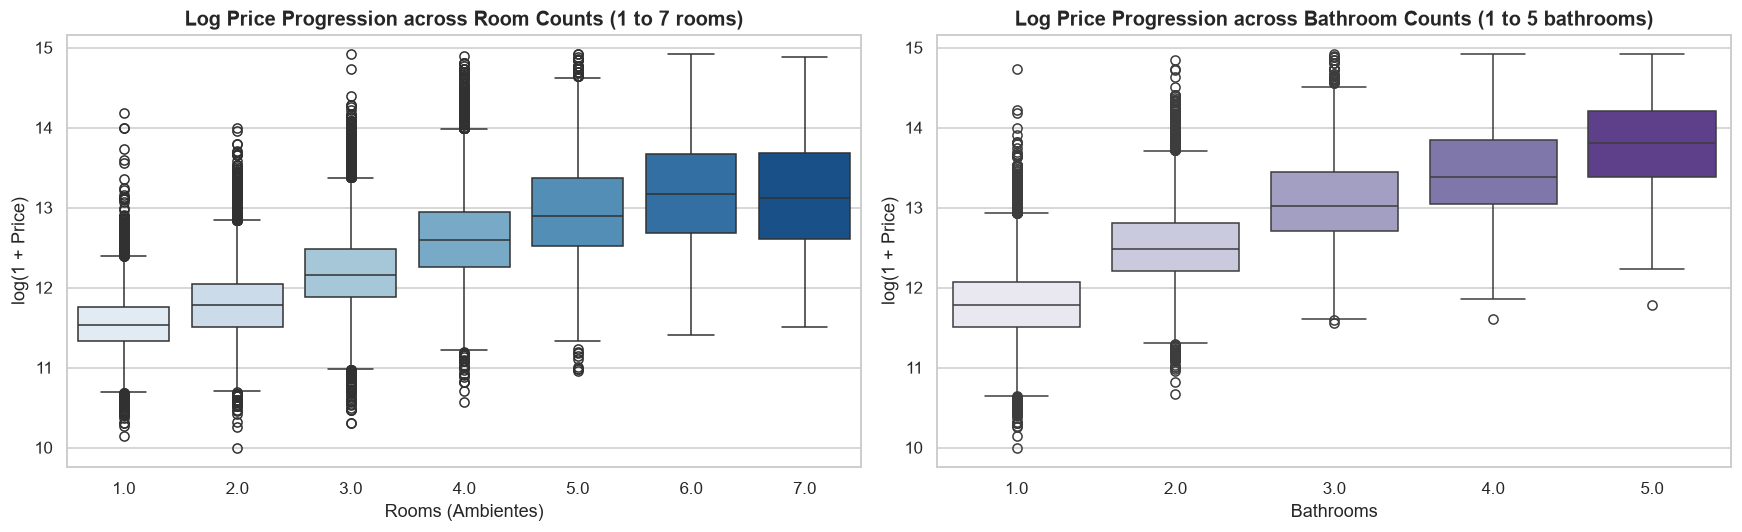

In [11]:
# Room and Bathroom steps progression
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(data=df[df['rooms'] <= 7], x='rooms', y='log_price', ax=axes[0], palette='Blues')
axes[0].set_title('Log Price Progression across Room Counts (1 to 7 rooms)')
axes[0].set_xlabel('Rooms (Ambientes)')
axes[0].set_ylabel('log(1 + Price)')

sns.boxplot(data=df[df['bathrooms'] <= 5], x='bathrooms', y='log_price', ax=axes[1], palette='Purples')
axes[1].set_title('Log Price Progression across Bathroom Counts (1 to 5 bathrooms)')
axes[1].set_xlabel('Bathrooms')
axes[1].set_ylabel('log(1 + Price)')

plt.tight_layout()
plt.show()


### Barrio Valuations: Top 10 Most Expensive vs Top 10 Most Accessible
We aggregate median price per $m^2$ across barrios with at least 50 listings to evaluate the spatial premium of CABA neighborhoods.


=== TOP 10 HIGHEST VALUATION BARRIOS (USD/m²) ===
               listing_count  median_price  mean_price  median_usd_m2
barrio                                                               
Puerto Madero            839    630,000.00  757,109.90       5,655.70
Las Cañitas              299    265,000.00  361,044.30       3,617.00
Palermo                 7861    215,000.00  322,889.50       3,265.30
Recoleta                3503    270,200.00  356,824.80       3,150.00
Belgrano                5168    240,000.00  354,698.40       3,142.90
Nuñez                   1835    210,000.00  276,543.30       3,073.20
Barrio Norte            1794    200,000.00  260,891.80       2,910.80
Retiro                   565    170,000.00  280,958.10       2,760.00
Coghlan                  484    180,000.00  218,035.10       2,722.20
Villa Urquiza           2719    168,500.00  200,549.10       2,705.90

=== TOP 10 ACCESSIBLE BARRIOS (USD/m²) ===
                   listing_count  median_price  mean_price  median

<string>:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

<string>:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

<string>:38: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


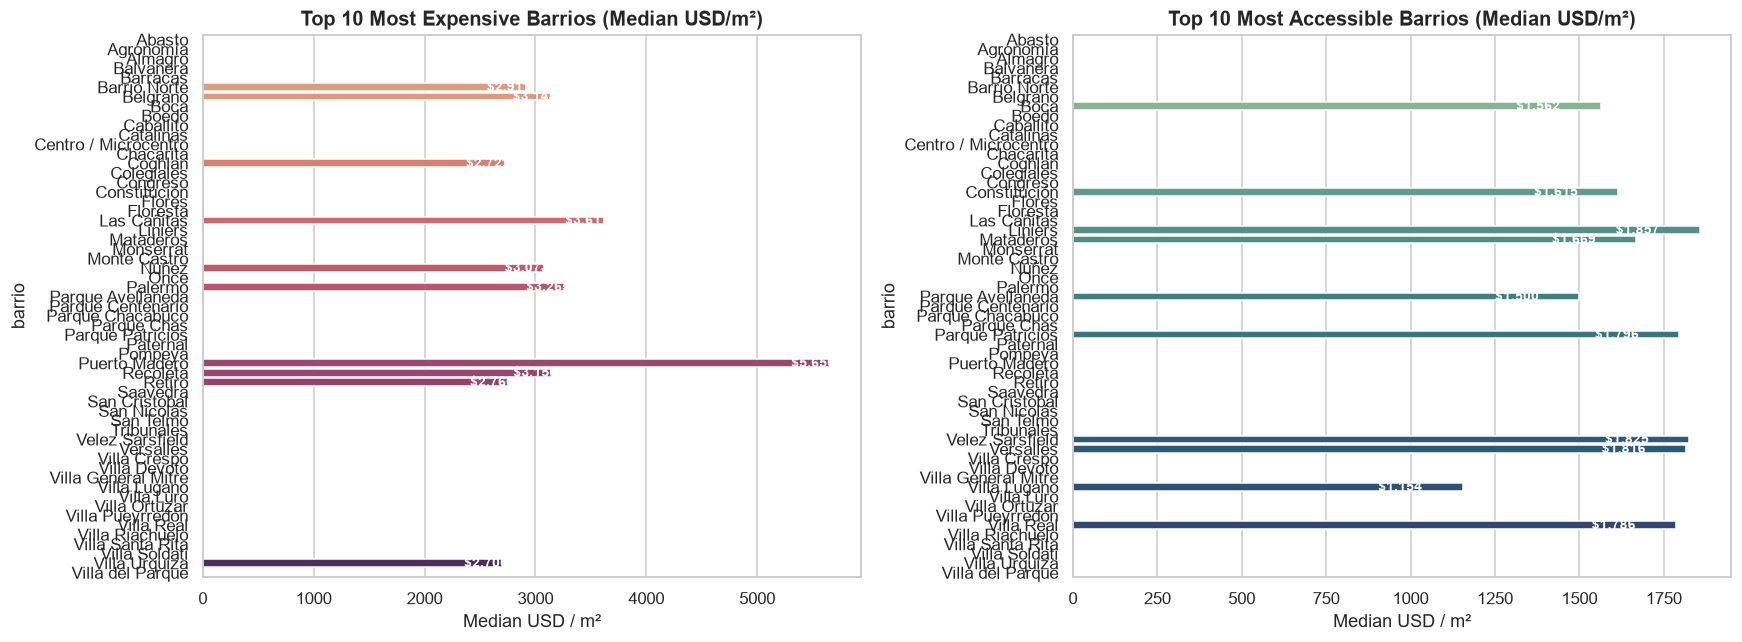

In [12]:
barrio_stats = df.groupby('barrio', observed=True).agg(
    listing_count=('price', 'count'),
    median_price=('price', 'median'),
    mean_price=('price', 'mean'),
    median_usd_m2=('price_usd_per_m2', 'median')
)

# Require at least 50 listings for reliable statistical sampling
barrio_reliable = barrio_stats[barrio_stats['listing_count'] >= 50]
top10_expensive = barrio_reliable.sort_values('median_usd_m2', ascending=False).head(10)
top10_accessible = barrio_reliable.sort_values('median_usd_m2', ascending=True).head(10)

print('=== TOP 10 HIGHEST VALUATION BARRIOS (USD/m²) ===')
print(top10_expensive.round(1))
print('\n=== TOP 10 ACCESSIBLE BARRIOS (USD/m²) ===')
print(top10_accessible.round(1))

# Visual Comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(y=top10_expensive.index, x=top10_expensive['median_usd_m2'], ax=axes[0], palette='flare')
axes[0].set_title('Top 10 Most Expensive Barrios (Median USD/m²)')
axes[0].set_xlabel('Median USD / m²')
for p in axes[0].patches:
    axes[0].annotate(f'${p.get_width():,.0f}',
                     (p.get_width() - 350, p.get_y() + p.get_height()/2.),
                     va='center', color='white', fontweight='bold', fontsize=9)

sns.barplot(y=top10_accessible.index, x=top10_accessible['median_usd_m2'], ax=axes[1], palette='crest')
axes[1].set_title('Top 10 Most Accessible Barrios (Median USD/m²)')
axes[1].set_xlabel('Median USD / m²')
for p in axes[1].patches:
    axes[1].annotate(f'${p.get_width():,.0f}',
                     (p.get_width() - 250, p.get_y() + p.get_height()/2.),
                     va='center', color='white', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()


## 7. Correlation & Multicollinearity Matrix
We compute both **Pearson Correlation** (capturing linear dependencies) and **Spearman Rank Correlation** (capturing monotonic dependencies without Gaussian assumptions), followed by a multicollinearity diagnostic.


=== CORRELATIONS WITH TARGET PRICE ===
                  Pearson r (Raw Price)  Spearman rho (Raw Price)  \
price                              1.00                      1.00   
log_price                          0.86                      1.00   
surface_covered                    0.78                      0.84   
surface_total                      0.73                      0.84   
rooms                              0.55                      0.70   
bathrooms                          0.69                      0.68   
bedrooms                           0.52                      0.68   
price_usd_per_m2                   0.50                      0.37   
lat                                0.21                      0.30   
lon                                0.12                      0.02   

                  Pearson r (Log Price)  
price                              0.86  
log_price                          1.00  
surface_covered                    0.77  
surface_total                    

<string>:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


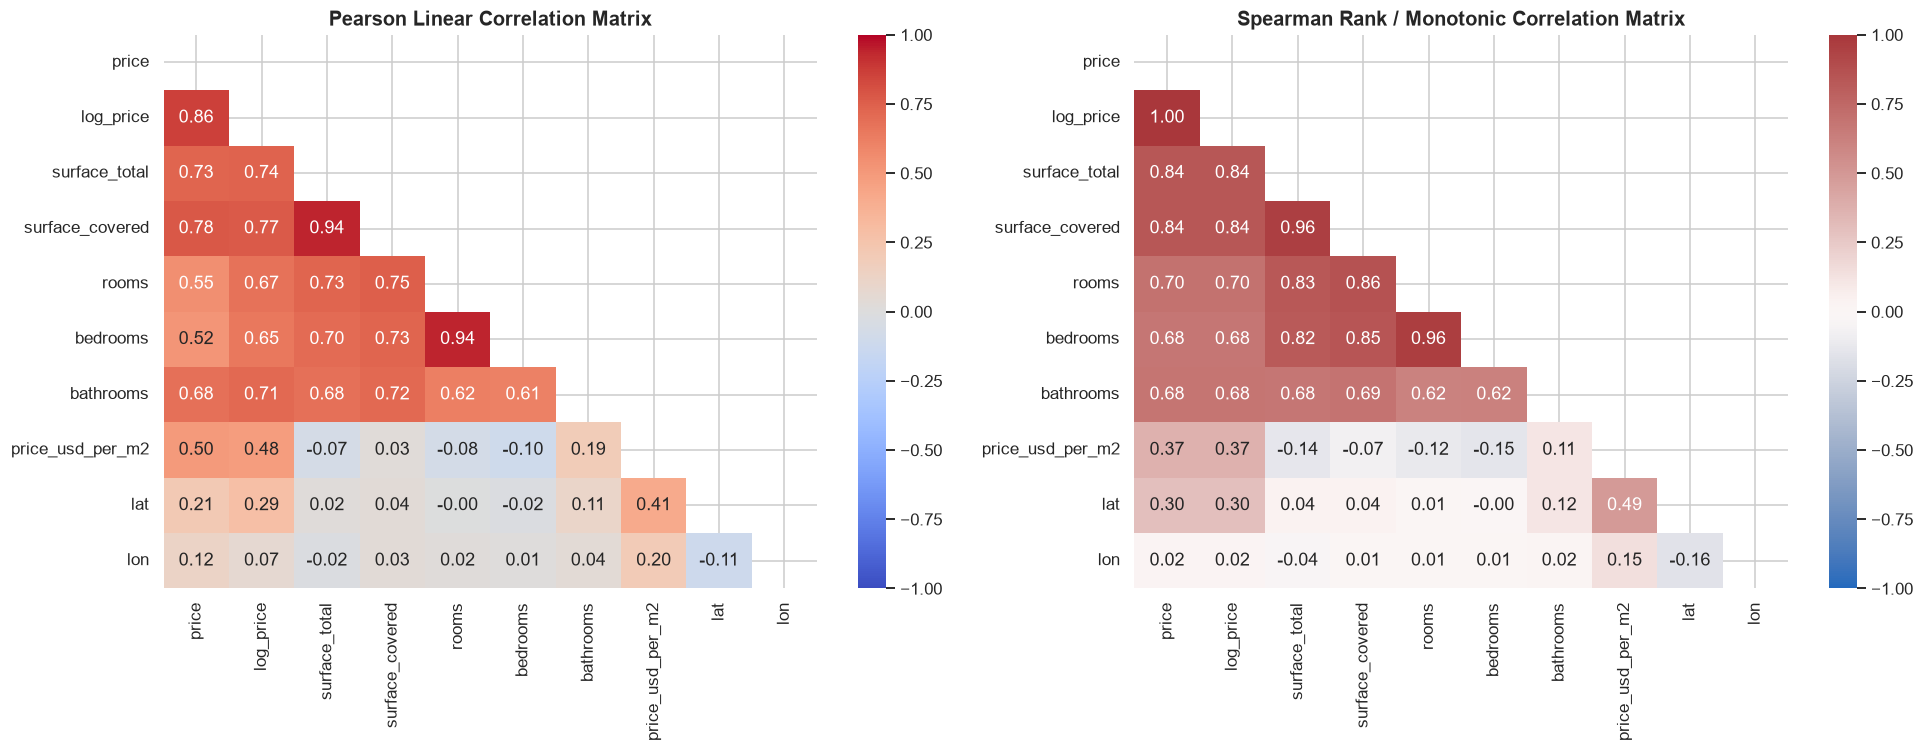

In [13]:
corr_cols = ['price', 'log_price', 'surface_total', 'surface_covered', 'rooms', 'bedrooms', 'bathrooms', 'price_usd_per_m2', 'lat', 'lon']
df_corr = df[corr_cols]

pearson_mat = df_corr.corr(method='pearson')
spearman_mat = df_corr.corr(method='spearman')

# Ranking correlation with Target Price
target_corr = pd.DataFrame({
    'Pearson r (Raw Price)': pearson_mat['price'],
    'Spearman rho (Raw Price)': spearman_mat['price'],
    'Pearson r (Log Price)': df_corr.corr(method='pearson')['log_price']
}).sort_values('Spearman rho (Raw Price)', ascending=False)

print('=== CORRELATIONS WITH TARGET PRICE ===')
print(target_corr.round(3))

# Heatmaps comparison
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

mask_p = np.triu(np.ones_like(pearson_mat, dtype=bool))
sns.heatmap(pearson_mat, mask=mask_p, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title('Pearson Linear Correlation Matrix')

mask_s = np.triu(np.ones_like(spearman_mat, dtype=bool))
sns.heatmap(spearman_mat, mask=mask_s, annot=True, fmt='.2f', cmap='vlag', vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title('Spearman Rank / Monotonic Correlation Matrix')

plt.tight_layout()
plt.show()


### Multicollinearity Diagnostic
Checking correlation between feature pairs to identify redundant predictors.


In [14]:
r_surfaces = df['surface_total'].corr(df['surface_covered'])
r_rooms = df['rooms'].corr(df['bedrooms'])

print('=== MULTICOLLINEARITY DIAGNOSTIC ===')
print(f'1. surface_total <-> surface_covered Pearson r: {r_surfaces:.3f}')
print(f'2. rooms <-> bedrooms Pearson r:                {r_rooms:.3f}')

print('\nInterpretation:')
print('- Surfaces share r = 0.944 correlation, and Rooms/Bedrooms share r = 0.945.')
print('- In linear models, fitting both simultaneously causes Variance Inflation (inflated standard errors and coefficient instability).')
print('- Action for Feature Engineering: Formulate ratios, such as `uncovered_ratio = (surface_total - surface_covered) / surface_total`.')


=== MULTICOLLINEARITY DIAGNOSTIC ===
1. surface_total <-> surface_covered Pearson r: 0.944
2. rooms <-> bedrooms Pearson r:                0.945

Interpretation:
- Surfaces share r = 0.944 correlation, and Rooms/Bedrooms share r = 0.945.
- In linear models, fitting both simultaneously causes Variance Inflation (inflated standard errors and coefficient instability).
- Action for Feature Engineering: Formulate ratios, such as `uncovered_ratio = (surface_total - surface_covered) / surface_total`.


## 8. Geospatial Price Dynamics in Capital Federal
Plotting coordinates ($Lon$ vs $Lat$) colored by valuation illustrates the well-known geographic socioeconomic gradient of Buenos Aires: Corredor Norte (*Puerto Madero, Recoleta, Palermo, Belgrano*) vs Sur (*Lugano, Soldati, Pompeya*).


<string>:21: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


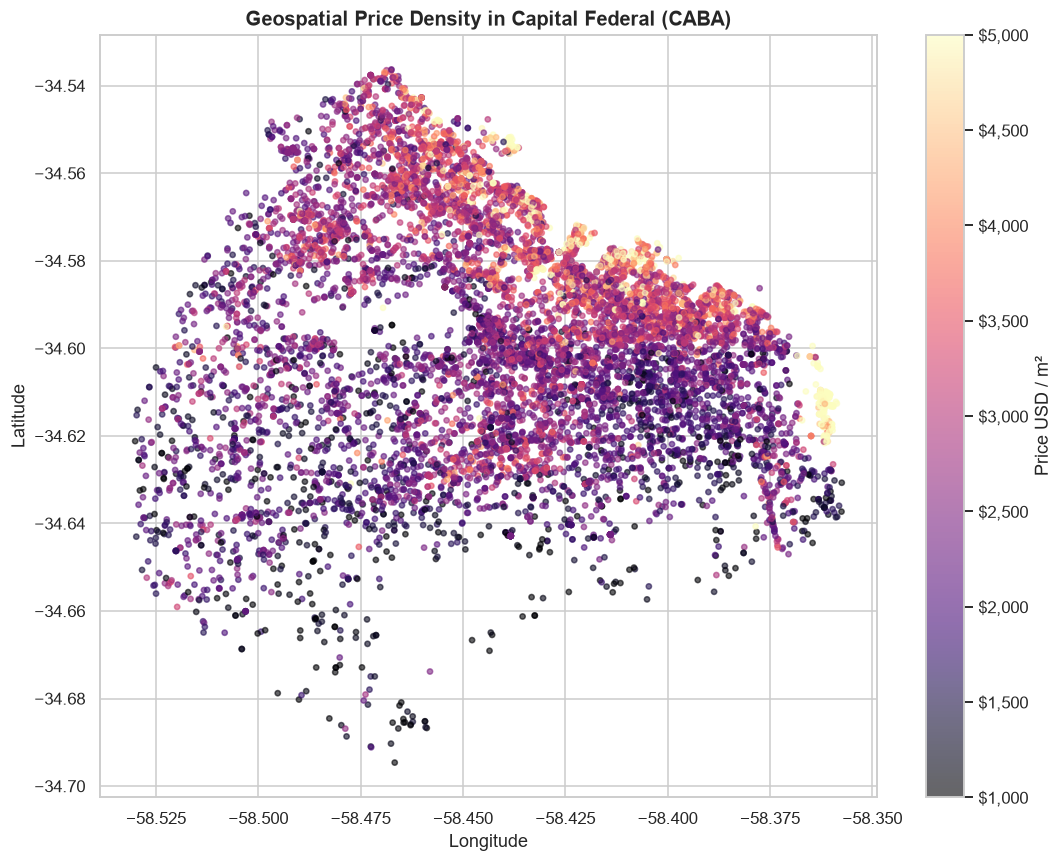

In [15]:
plt.figure(figsize=(10, 8))
sample_geo = df.sample(min(10000, len(df)), random_state=42)

sc = plt.scatter(
    sample_geo['lon'],
    sample_geo['lat'],
    c=sample_geo['price_usd_per_m2'],
    cmap='magma',
    s=12,
    alpha=0.6,
    vmin=1000,
    vmax=5000
)
cb = plt.colorbar(sc, label='Price USD / m²')
cb.ax.yaxis.set_major_formatter(lambda x, pos: f'${x:,.0f}')

plt.title('Geospatial Price Density in Capital Federal (CABA)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.show()


## 9. Strategic Synthesis & Feature Engineering Roadmap

From this comprehensive EDA, we extract concrete guidelines for `03_feature_engineering.ipynb`:

| Domain | Finding | Actionable Directive for Feature Engineering |
| :--- | :--- | :--- |
| **Target Variable** | Right-skewed distribution ($Sesgo = 4.20$). Log transform yields quasi-normal distribution ($Sesgo = 0.80$). | Model target must be $\mathbf{y = \log(1 + Price)}$. Invert predictions with $\exp(y) - 1$ during evaluation. |
| **Surface Redundancy** | $Surface_{total}$ and $Surface_{covered}$ are collinear ($r = 0.944$). | Create **`uncovered_surface`** ($Surface_{total} - Surface_{covered}$) and **`uncovered_ratio`**. Keep $Surface_{total}$ or log-transformed surface as primary size proxy. |
| **Room Redundancy** | $Rooms$ and $Bedrooms$ are collinear ($r = 0.945$). | Create a binary flag **`is_monoambiente`** ($Rooms == 1$) and interaction feature **`avg_room_surface`** ($Surface / Rooms$). |
| **Neighborhood Variance** | 5x valuation disparity across barrios (Puerto Madero ~$5,600/m² vs Lugano ~$1,150/m²). | Apply **Target Encoding with K-Fold Regularization** or Frequency Encoding on `barrio`. |
| **Spatial Coordinates** | Latitude correlates with price ($r = 0.30$) due to the North-South socioeconomic corridor. | Engineer spatial features: Euclidean distance to financial center (*Obelisco* / Microcentro) and distance to coastal parks (*Río de la Plata*). |
| **Property Type** | Houses have lower price/m² but higher total surface than apartments. | One-Hot Encode `property_type` and interact with `surface_total`. |
